# Analysis of InfoGap's annotations of WikiMT data

## Compute Symmetric Reference Divergence

For each article pair, we compute a **symmetric reference divergence** metric based on the yes/no intersection labels from the InfoGap pipeline:

$$D_{\text{yes/no}} = 1 - \frac{Y_S + Y_T}{F_S + F_T}$$

Where:
- $F_S$ = number of facts in source article
- $F_T$ = number of facts in target article  
- $Y_S$ = number of source facts present in target (sum of yes labels)
- $Y_T$ = number of target facts present in source (sum of yes labels)

**Interpretation**: This measures the fraction of facts that are *unmatched* across both sides. A value of 0 means perfect overlap; 1 means no overlap.

In [2]:
import os
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ==============================================================================
# STEP 1: Load annotation files and detect duplicates
# ==============================================================================

annotation_dir = ANNOTATIONS_DIR
annotation_files = list(Path(annotation_dir).glob("annotation_*.json"))

print(f"Found {len(annotation_files)} total annotation files\n")

# Group files by article name (extract from filename)
# Filename format: annotation_YYYY-MM-DD_ArticleName_lang.json
article_files = defaultdict(list)

for f in annotation_files:
    # Parse filename: annotation_2025-10-27_Article Name_fr.json
    # Strategy: split by '_', extract date (position 1), and reconstruct article name
    parts = f.stem.split('_')
    
    if len(parts) >= 3:
        date = parts[1]  # '2025-10-27'
        lang = parts[-1]  # 'fr' or 'en'
        
        # Article name is everything between date and language
        article_name_parts = parts[2:-1]
        article_name = '_'.join(article_name_parts)
        
        # Use article name + language as unique key
        unique_key = f"{article_name}_{lang}"
        
        article_files[unique_key].append((date, f))

# Count unique articles (ignoring language suffix)
unique_articles = set()
for key in article_files.keys():
    article_base = '_'.join(key.split('_')[:-1]) if '_' in key else key
    unique_articles.add(article_base)

print(f"Found {len(unique_articles)} unique articles ({len(article_files)} article-language pairs)")

# ==============================================================================
# STEP 2: Remove duplicates (keep most recent)
# ==============================================================================

duplicates_found = 0
files_to_remove = []

for article_key, files in article_files.items():
    if len(files) > 1:
        duplicates_found += 1
        # Sort by date (descending) to keep the most recent
        files.sort(reverse=True)
        most_recent = files[0]
        older_files = files[1:]
        
        print(f"\n  Duplicate: {article_key}")
        print(f"    ✓ Keeping:  {most_recent[1].name} ({most_recent[0]})")
        for date, f in older_files:
            print(f"    ✗ Removing: {f.name} ({date})")
            files_to_remove.append(f)

if files_to_remove:
    print(f"\n{'='*70}")
    print(f"Found {len(files_to_remove)} duplicate files - removing them...")
    print(f"{'='*70}\n")
    
    for f in files_to_remove:
        f.unlink()
        print(f"  Deleted: {f.name}")
    
    print(f"\n✓ Cleanup complete! Removed {len(files_to_remove)} files.")
    
    # Refresh file list after deletion
    annotation_files = list(annotation_dir.glob("annotation_*.json"))
    print(f"✓ {len(annotation_files)} files remaining\n")
else:
    print("\n✓ No duplicate files found!\n")

# ==============================================================================
# STEP 3: Load annotation files into DataFrames
# ==============================================================================

print(f"{'='*70}")
print("Loading annotation files...")
print(f"{'='*70}\n")

output_dfs = []

for ann_file in annotation_files:
    try:
        with open(ann_file, 'r') as f:
            data = json.load(f)
        
        # Parse the Polars JSON structure
        columns_data = {}
        for col in data['columns']:
            col_name = col['name']
            values = col['values']
            
            # Handle nested list structures
            if col['datatype'] == {'List': 'Utf8'} or \
               col['datatype'] == {'List': {'List': 'Utf8'}} or \
               col['datatype'] == {'List': 'Float64'}:
                columns_data[col_name] = values
            else:
                columns_data[col_name] = values
        
        # Create DataFrame with key columns
        df = pd.DataFrame({
            'fact': columns_data['fact'],
            'person_name': columns_data['person_name'],
            'language': columns_data['language'],
            'intersection_label': columns_data['intersection_label']
        })
        
        # Store filename for reference
        df.attrs['filename'] = ann_file.name
        
        output_dfs.append(df)
        
    except Exception as e:
        print(f"  ✗ Error loading {ann_file.name}: {e}")
        continue

print(f"✓ Successfully loaded {len(output_dfs)} annotation files\n")

# ==============================================================================
# STEP 4: Compute divergence for each article pair
# ==============================================================================

print(f"{'='*70}")
print("Computing reference divergence...")
print(f"{'='*70}\n")

def compute_reference_divergence(df, min_facts=6):
    """
    Compute symmetric reference divergence for an article pair.
    
    Returns dict with divergence metrics.
    """
    # Identify source and target languages
    languages = df['language'].unique()
    if len(languages) != 2:
        return {
            'divergence': None,
            'F_S': 0, 'F_T': 0, 'Y_S': 0, 'Y_T': 0,
            'excluded': True,
            'reason': f'Expected 2 languages, found {len(languages)}'
        }
    
    src_lang, tgt_lang = languages[0], languages[1]
    
    # Get source and target subsets
    df_src = df[df['language'] == src_lang]
    df_tgt = df[df['language'] == tgt_lang]
    
    # Count facts
    F_S = len(df_src)
    F_T = len(df_tgt)
    
    # Check minimum threshold
    if F_S + F_T < min_facts:
        return {
            'divergence': None,
            'F_S': F_S, 'F_T': F_T, 'Y_S': 0, 'Y_T': 0,
            'excluded': True,
            'reason': f'Too few facts: F_S + F_T = {F_S + F_T} < {min_facts}'
        }
    
    # Count matches (yes labels)
    def count_yes(labels_series):
        count = 0
        for label in labels_series:
            if isinstance(label, str):
                label_lower = label.lower().strip()
                if label_lower == 'yes' or label_lower == 'y':
                    count += 1
        return count
    
    Y_S = count_yes(df_src['intersection_label'])
    Y_T = count_yes(df_tgt['intersection_label'])
    
    # Compute divergence
    divergence = 1 - (Y_S + Y_T) / (F_S + F_T)
    
    return {
        'divergence': divergence,
        'F_S': F_S,
        'F_T': F_T,
        'Y_S': Y_S,
        'Y_T': Y_T,
        'excluded': False,
        'reason': None,
        'src_lang': src_lang,
        'tgt_lang': tgt_lang
    }

# Compute divergence for each article pair
divergence_results = []

for i, df in enumerate(output_dfs):
    result = compute_reference_divergence(df, min_facts=6)
    
    # Get article name
    if 'person_name' in df.columns:
        person_names = df['person_name'].unique()
        article_name = person_names[0] if len(person_names) > 0 else f'Article_{i}'
    else:
        article_name = f'Article_{i}'
    
    result['article'] = article_name
    result['filename'] = df.attrs.get('filename', f'unknown_{i}')
    divergence_results.append(result)
    
    # Print result
    if result['excluded']:
        print(f"⚠️  {article_name}: EXCLUDED - {result['reason']}")
    else:
        src_lang = result.get('src_lang', 'src')
        tgt_lang = result.get('tgt_lang', 'tgt')
        print(f"✓ {article_name} ({src_lang}↔{tgt_lang}):")
        print(f"  D_yes/no = {result['divergence']:.3f}")
        print(f"  Facts: F_{src_lang}={result['F_S']}, F_{tgt_lang}={result['F_T']}")
        print(f"  Matched: Y_{src_lang}={result['Y_S']}, Y_{tgt_lang}={result['Y_T']}")
        if result['F_S'] > 0 and result['F_T'] > 0:
            print(f"  Recall_{src_lang}={result['Y_S']/result['F_S']:.2%}, "
                  f"Recall_{tgt_lang}={result['Y_T']/result['F_T']:.2%}")
        print()

# ==============================================================================
# STEP 5: Create summary DataFrame
# ==============================================================================

divergence_df = pd.DataFrame(divergence_results)

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
display_cols = ['article', 'divergence', 'F_S', 'F_T', 'Y_S', 'Y_T', 'excluded']
print(divergence_df[display_cols].to_string(index=False))

non_excluded = divergence_df[~divergence_df['excluded']]
if len(non_excluded) > 0:
    print(f"\nStatistics (non-excluded articles):")
    print(f"  Count: {len(non_excluded)}")
    print(f"  Mean divergence: {non_excluded['divergence'].mean():.3f}")
    print(f"  Median divergence: {non_excluded['divergence'].median():.3f}")
    print(f"  Min divergence: {non_excluded['divergence'].min():.3f}")
    print(f"  Max divergence: {non_excluded['divergence'].max():.3f}")
    print(f"  Std divergence: {non_excluded['divergence'].std():.3f}")
else:
    print("\n⚠️  No valid article pairs to compute statistics")

# Display the DataFrame
divergence_df.head(3)


/Users/llupo/miniconda3/envs/mentalenv/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Found 217 total annotation files

Found 217 unique articles (217 article-language pairs)

✓ No duplicate files found!

Loading annotation files...

✓ Successfully loaded 217 annotation files

Computing reference divergence...

✓ Benjamin Smith (Whig politician) (en↔fr):
  D_yes/no = 0.101
  Facts: F_en=51, F_fr=38
  Matched: Y_en=47, Y_fr=33
  Recall_en=92.16%, Recall_fr=86.84%

✓ Muskrat River (Ontario) (fr↔en):
  D_yes/no = 0.222
  Facts: F_fr=9, F_en=18
  Matched: Y_fr=9, Y_en=12
  Recall_fr=100.00%, Recall_en=66.67%

⚠️  Retaliate (Misery Index album): EXCLUDED - Too few facts: F_S + F_T = 3 < 6
✓ Private town (en↔fr):
  D_yes/no = 0.235
  Facts: F_en=47, F_fr=21
  Matched: Y_en=36, Y_fr=16
  Recall_en=76.60%, Recall_fr=76.19%

✓ Charles Cust (en↔fr):
  D_yes/no = 0.184
  Facts: F_en=20, F_fr=18
  Matched: Y_en=15, Y_fr=16
  Recall_en=75.00%, Recall_fr=88.89%

✓ Mastoid cells (fr↔en):
  D_yes/no = 0.120
  Facts: F_fr=24, F_en=26
  Matched: Y_fr=22, Y_en=22
  Recall_fr=91.67%, Recal

,divergence,F_S,F_T,Y_S,Y_T,excluded,reason,src_lang,tgt_lang,article,filename
0,0.101124,51,38,47,33,False,None,en,fr,Benjamin Smith (Whig politician),annotation_2025-10-27_Benjamin Smith (Whig pol...
1,0.222222,9,18,9,12,False,None,fr,en,Muskrat River (Ontario),annotation_2025-10-31_Muskrat River (Ontario)_...
2,NaN,1,2,0,0,True,Too few facts: F_S + F_T = 3 < 6,NaN,NaN,Retaliate (Misery Index album),annotation_2025-10-28_Retaliate (Misery Index ...


## Match InfoGap Articles with Wiki_MT Groups

This section:
1. Loads Wiki_MT treatment and control divergence parquet files
2. Maps QIDs to article titles for control group (using JSON file)
3. Creates article-to-group mapping
4. Assigns each InfoGap article to treatment/control group

**Note**: Control group parquet only has QIDs, not article titles, so we need to map them from the JSON source.

## Statistical Test: Treatment vs Control Groups

Test whether InfoGap divergence differs significantly between treatment and control groups.


⚠️  Only treatment group available - showing treatment distribution only


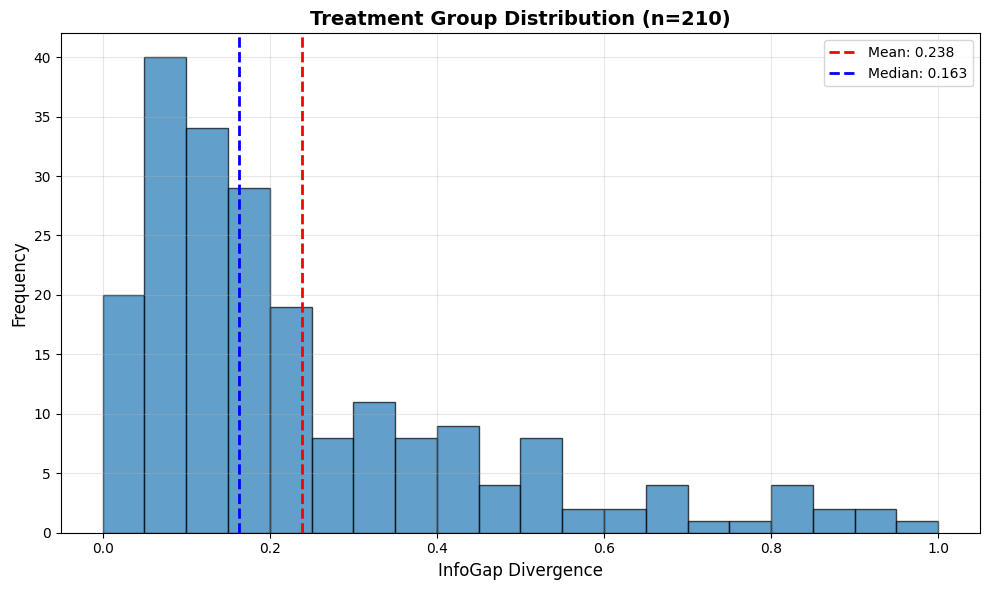

In [5]:
# ==============================================================================
# Visualize Treatment vs Control Divergence
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Check if we have both groups
n_treatment = (comparison_df['wikimt_group'] == 'treatment').sum()
n_control = (comparison_df['wikimt_group'] == 'control').sum()

if n_treatment > 0 and n_control > 0:
    print(f"\n{'='*80}")
    print("Visualizing Treatment vs Control")
    print(f"{'='*80}\n")
    
    # Create figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('InfoGap Divergence: Treatment vs Control', fontsize=16, fontweight='bold')
    
    # 1. Box plot
    ax = axes[0, 0]
    sns.boxplot(data=comparison_df, x='wikimt_group', y='divergence', ax=ax)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('InfoGap Divergence', fontsize=12)
    ax.set_title('Distribution by Group', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 2. Violin plot
    ax = axes[0, 1]
    sns.violinplot(data=comparison_df, x='wikimt_group', y='divergence', ax=ax)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('InfoGap Divergence', fontsize=12)
    ax.set_title('Density Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 3. Histogram
    ax = axes[1, 0]
    treatment_div = comparison_df[comparison_df['wikimt_group'] == 'treatment']['divergence']
    control_div = comparison_df[comparison_df['wikimt_group'] == 'control']['divergence']
    
    ax.hist([treatment_div, control_div], bins=20, alpha=0.6, label=['Treatment', 'Control'])
    ax.set_xlabel('InfoGap Divergence', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Histogram Comparison', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Strip plot with means
    ax = axes[1, 1]
    sns.stripplot(data=comparison_df, x='wikimt_group', y='divergence', alpha=0.4, ax=ax)
    
    # Add mean lines
    for group in ['treatment', 'control']:
        group_mean = comparison_df[comparison_df['wikimt_group'] == group]['divergence'].mean()
        x_pos = 0 if group == 'treatment' else 1
        ax.plot([x_pos - 0.3, x_pos + 0.3], [group_mean, group_mean], 
                color='red', linewidth=2, label=f'{group.capitalize()} mean' if group == 'treatment' else None)
    
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('InfoGap Divergence', fontsize=12)
    ax.set_title('Individual Points with Means', fontsize=12, fontweight='bold')
    ax.legend(['Mean'], loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional: QQ-plot to check normality
    from scipy import stats
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Normality Check: QQ-Plots', fontsize=14, fontweight='bold')
    
    for i, group in enumerate(['treatment', 'control']):
        group_data = comparison_df[comparison_df['wikimt_group'] == group]['divergence']
        stats.probplot(group_data, dist="norm", plot=axes[i])
        axes[i].set_title(f'{group.capitalize()} Group (n={len(group_data)})', fontsize=12)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

elif n_treatment > 0:
    print(f"\n⚠️  Only treatment group available - showing treatment distribution only")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    treatment_div = comparison_df[comparison_df['wikimt_group'] == 'treatment']['divergence']
    
    ax.hist(treatment_div, bins=20, alpha=0.7, edgecolor='black')
    ax.axvline(treatment_div.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {treatment_div.mean():.3f}')
    ax.axvline(treatment_div.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {treatment_div.median():.3f}')
    ax.set_xlabel('InfoGap Divergence', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'Treatment Group Distribution (n={len(treatment_div)})', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n❌ No data available for visualization")

## Compare InfoGap vs Wiki_MT Divergence Scores

Compare our InfoGap divergence metric with Wiki_MT's existing divergence scores (prop_above_threshold) for the same articles.

In [8]:
# ==============================================================================
# Correlation Analysis: InfoGap vs Wiki_MT Divergence
# ==============================================================================

if len(method_comparison_df) > 0 and 'wikimt_prop_above_threshold' in method_comparison_df.columns:
    print(f"\n{'='*80}")
    print("Correlation Analysis")
    print(f"{'='*80}")
    
    # Clean data (remove NaN values)
    clean_df = method_comparison_df.dropna(subset=['infogap_divergence', 'wikimt_prop_above_threshold'])
    
    if len(clean_df) >= 3:
        from scipy import stats
        
        infogap_scores = clean_df['infogap_divergence']
        wikimt_scores = clean_df['wikimt_prop_above_threshold']
        
        # Pearson correlation
        pearson_r, pearson_p = stats.pearsonr(infogap_scores, wikimt_scores)
        print(f"\nPearson correlation:")
        print(f"  r = {pearson_r:.4f}")
        print(f"  p-value = {pearson_p:.4f}")
        
        if pearson_p < 0.05:
            print(f"  ✅ Significant correlation (p < 0.05)")
        else:
            print(f"  ⚠️  Not significant (p >= 0.05)")
        
        # Spearman correlation (rank-based, more robust)
        spearman_r, spearman_p = stats.spearmanr(infogap_scores, wikimt_scores)
        print(f"\nSpearman correlation (rank-based):")
        print(f"  ρ = {spearman_r:.4f}")
        print(f"  p-value = {spearman_p:.4f}")
        
        if spearman_p < 0.05:
            print(f"  ✅ Significant correlation (p < 0.05)")
        else:
            print(f"  ⚠️  Not significant (p >= 0.05)")
        
        # Summary statistics
        print(f"\n{'='*80}")
        print("Summary Statistics")
        print(f"{'='*80}")
        print(f"\nInfoGap Divergence:")
        print(f"  Mean: {infogap_scores.mean():.4f}")
        print(f"  Std: {infogap_scores.std():.4f}")
        print(f"  Range: [{infogap_scores.min():.4f}, {infogap_scores.max():.4f}]")
        
        print(f"\nWiki_MT Divergence (prop_above_threshold):")
        print(f"  Mean: {wikimt_scores.mean():.4f}")
        print(f"  Std: {wikimt_scores.std():.4f}")
        print(f"  Range: [{wikimt_scores.min():.4f}, {wikimt_scores.max():.4f}]")
    else:
        print(f"\n⚠️  Insufficient data for correlation analysis (n={len(clean_df)})")
else:
    print(f"\n⚠️  No Wiki_MT divergence scores available for comparison")


Correlation Analysis

Pearson correlation:
  r = 0.7474
  p-value = 0.0000
  ✅ Significant correlation (p < 0.05)

Spearman correlation (rank-based):
  ρ = 0.6372
  p-value = 0.0000
  ✅ Significant correlation (p < 0.05)

Summary Statistics

InfoGap Divergence:
  Mean: 0.2380
  Std: 0.2125
  Range: [0.0000, 1.0000]

Wiki_MT Divergence (prop_above_threshold):
  Mean: 0.1034
  Std: 0.1365
  Range: [0.0000, 0.6905]
